<a href="https://colab.research.google.com/github/anjali011111/Network-Port-Scanner/blob/main/venuratech(mini)%5BRESUME_PARSER_AI%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Libraries loaded!
✅ Preprocessing functions ready!
✅ Loaded 9 resumes
📊 Categories: 3

category
Data Science       3
Java Developer     3
React Developer    3
Name: count, dtype: int64
🔄 Preprocessing resumes (this takes ~30 seconds)...
✅ Preprocessing complete!

Sample processed resume:
machine learning expert year python tensorflow scikit learn strong sql statistic expertise built nlp model text classification aws sagemaker experience...
📊 Building TF-IDF matrix...
✅ TF-IDF matrix shape: (9, 246)
   (9 resumes × 246 features)

🔵 Clustering resumes...
✅ Clustered into 3 groups
📌 TOP TERMS PER CLUSTER:

Cluster 0 (React Developer):
  react, component, cs, api, javascript, year, practice, performance optimization, performance, optimization seo

Cluster 1 (Java Developer):
  spring, java, rest, year java, rest apis, spring boot, apis, boot, year, stack

Cluster 2 (Data Science):
  data, sql, python, statistic, model, experience, year, testing python, tableau powerbi, statistic hypothes

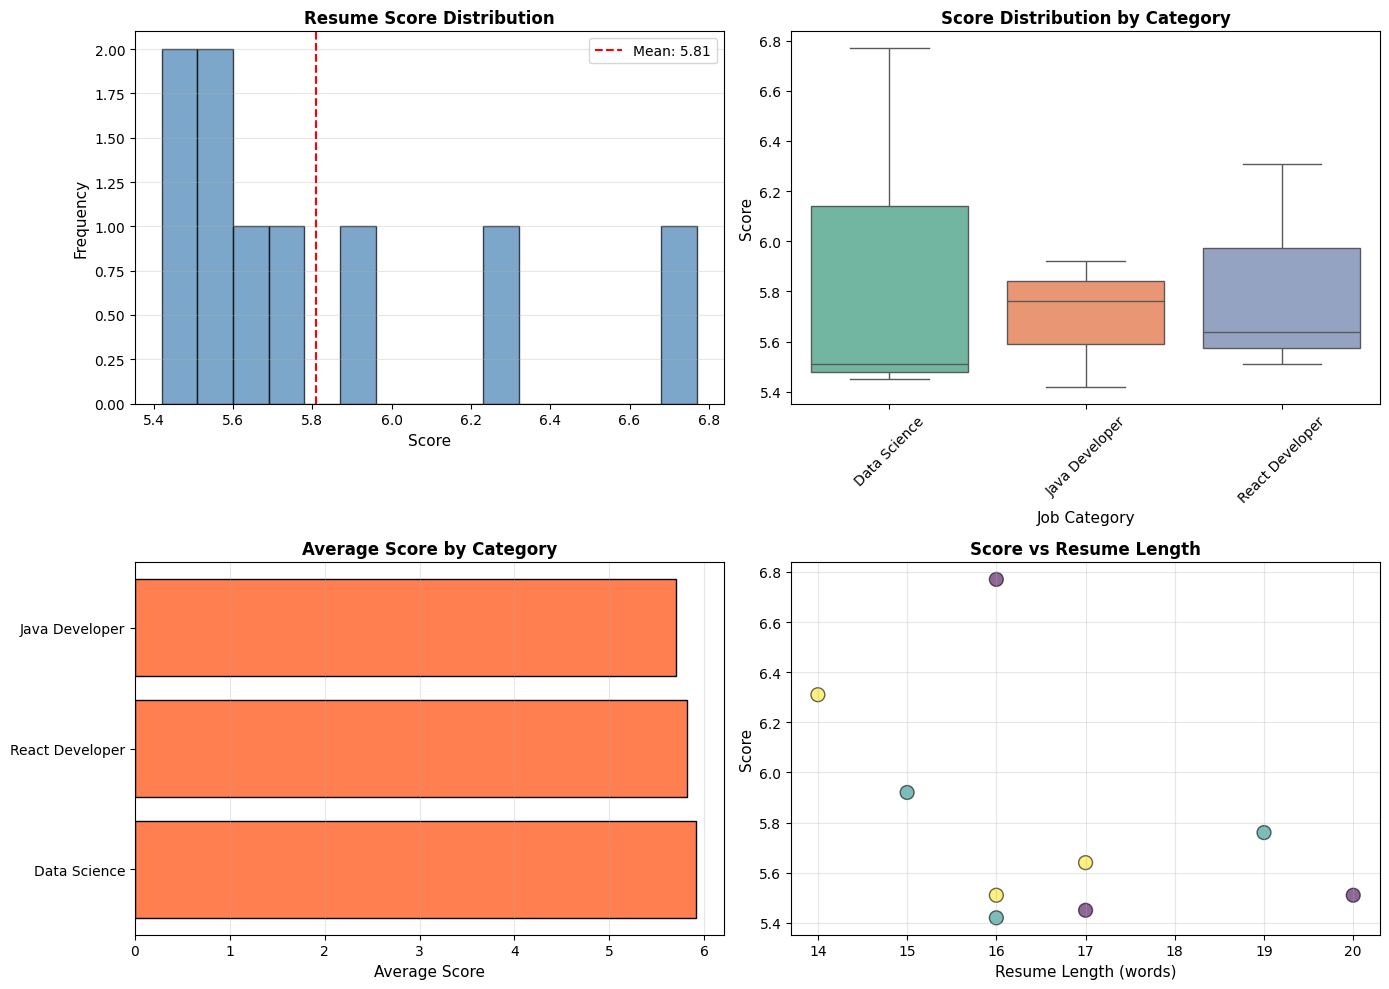

✅ Visualization saved as resume_analysis.png
✅ Results saved to resume_scores.csv


,category,cluster_id,score,text_length
rank,,,,
0,Data Science,2,6.77,16
1,React Developer,0,6.31,14
2,Java Developer,1,5.92,15
3,Java Developer,1,5.76,19
4,React Developer,0,5.64,17
5,Data Science,2,5.51,20
6,React Developer,0,5.51,16
7,Data Science,2,5.45,17
8,Java Developer,1,5.42,16



DETAILED ANALYSIS: Resume #0
Category:      Data Science
Score:         5.51/10
Cluster:       2
Length:        20 words

Original Resume:
Machine Learning expert with 5 years in Python TensorFlow scikit-learn. Strong SQL statistics expertise. Built NLP models for text classification. AWS SageMaker experience....

Processed Resume:
machine learning expert year python tensorflow scikit learn strong sql statistic expertise built nlp model text classification aws sagemaker experience...


In [4]:
# ============================================================================
# RESUME PARSER AI - GOOGLE COLAB VERSION
# ============================================================================
# This notebook scores candidate resumes from 0-10 using NLP & clustering
# ============================================================================

# Install required libraries
!pip install nltk scikit-learn pandas numpy -q

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

import re
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

# ============================================================================
# SECTION 1: TEXT PREPROCESSING
# ============================================================================

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Remove URLs, punctuation, numbers, and extra spaces."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

def tokenize_and_lemmatize(text: str) -> list:
    """Tokenize, remove stopwords, and lemmatize."""
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

def preprocess(text: str) -> str:
    """Full pipeline: clean → tokenize → lemmatize → rejoin."""
    cleaned = clean_text(text)
    tokens = tokenize_and_lemmatize(cleaned)
    return ' '.join(tokens)

print("✅ Preprocessing functions ready!")

# ============================================================================
# SECTION 2: LOAD DATASET
# ============================================================================
# Option 1: Download from Kaggle
# Option 2: Use sample data

# OPTION A: If using Kaggle API
# from google.colab import files
# files.upload()  # Upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d gauravduttakiit/resume-dataset
# !unzip -q resume-dataset.zip

# OPTION B: For demo, create sample data
sample_resumes = {
    'category': [
        'Data Science', 'Data Science', 'Data Science',
        'Java Developer', 'Java Developer', 'Java Developer',
        'React Developer', 'React Developer', 'React Developer'
    ],
    'resume': [
        'Machine Learning expert with 5 years in Python TensorFlow scikit-learn. Strong SQL statistics expertise. Built NLP models for text classification. AWS SageMaker experience.',
        '3 years data science background. Pandas numpy sklearn. SQL databases. Jupyter notebooks. Python scripting. Data visualization matplotlib seaborn.',
        'Data analyst turned scientist. 4 years experience. Statistics hypothesis testing. Python ML models. SQL queries optimization. Tableau PowerBI.',
        'Senior Java developer 8 years OOP design patterns Spring Boot microservices REST APIs. JUnit testing Maven gradle. PostgreSQL MySQL databases.',
        '5 years Java backend. Spring framework REST web services. JPA Hibernate ORM. Multithreading concurrency. Problem solving algorithms.',
        '6 years Java full stack. Spring Boot REST APIs. JavaScript frontend. Docker containerization. CI/CD Jenkins. Agile scrum.',
        'React specialist 4 years. JavaScript ES6 Redux state management. CSS Tailwind responsive design. REST API integration. Jest testing.',
        '3 years frontend React developer. Component architecture hooks context API. HTML CSS JavaScript. webpack bundling. Git version control.',
        'React JS 5 years experience. TypeScript advanced. Material UI components. Axios HTTP. Performance optimization. SEO best practices.'
    ]
}

df = pd.read_csv('https://www.kaggle.com/datasets/gauravduttakiit/resume-dataset') if False else pd.DataFrame(sample_resumes)

df.columns = [c.lower().strip() for c in df.columns]
df = df.rename(columns={'resume': 'resume_text'} if 'resume' in df.columns else {})
df = df.dropna(subset=['resume_text'])

print(f"✅ Loaded {len(df)} resumes")
print(f"📊 Categories: {df['category'].nunique()}")
print(f"\n{df['category'].value_counts()}")
# ============================================================================
# SECTION 3: PREPROCESS ALL RESUMES
# ============================================================================

print("🔄 Preprocessing resumes (this takes ~30 seconds)...")
df['processed'] = df['resume_text'].apply(preprocess)
df['text_length'] = df['processed'].apply(lambda x: len(x.split()))

print(f"✅ Preprocessing complete!")
print(f"\nSample processed resume:\n{df['processed'].iloc[0][:200]}...")
# ============================================================================
# SECTION 4: BUILD TF-IDF MATRIX & CLUSTERING
# ============================================================================

print("📊 Building TF-IDF matrix...")
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=1)
tfidf_matrix = vectorizer.fit_transform(df['processed'].tolist())

print(f"✅ TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"   ({len(df)} resumes × {tfidf_matrix.shape[1]} features)")

print("\n🔵 Clustering resumes...")
n_clusters = df['category'].nunique()
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tfidf_matrix)
df['cluster_id'] = cluster_labels

print(f"✅ Clustered into {n_clusters} groups")
# ============================================================================
# SECTION 5: EXTRACT TOP CLUSTER TERMS
# ============================================================================

def get_top_cluster_terms(kmeans_model, vectorizer, top_n=10):
    order_centroids = kmeans_model.cluster_centers_.argsort()[:, ::-1]
    terms = vectorizer.get_feature_names_out()
    cluster_terms = {}
    for i, centroid in enumerate(order_centroids):
        cluster_terms[i] = [terms[idx] for idx in centroid[:top_n]]
    return cluster_terms

cluster_terms = get_top_cluster_terms(kmeans, vectorizer)

print("📌 TOP TERMS PER CLUSTER:\n")
for cid, terms in cluster_terms.items():
    category = df[df['cluster_id'] == cid]['category'].iloc[0] if len(df[df['cluster_id'] == cid]) > 0 else "Unknown"
    print(f"Cluster {cid} ({category}):")
    print(f"  {', '.join(terms)}\n")
# ============================================================================
# SECTION 6: SCORING FUNCTION
# ============================================================================

def extract_experience_years(text: str) -> int:
    """Extract years of experience from resume text."""
    patterns = [
        r'(\d+)\+?\s*years?\s+of\s+experience',
        r'(\d+)\+?\s*years?\s+experience',
        r'experience\s+of\s+(\d+)\+?\s*years?',
    ]
    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return int(match.group(1))
    return 0

def score_resume(resume_vector, job_vector, experience_years: int = 0, required_exp: int = 3) -> float:
    """
    Score a resume against a job description (0-10).
    Uses contextual cosine similarity, not just keyword matching.
    """
    similarity = cosine_similarity(resume_vector, job_vector)[0][0]
    exp_score = min(experience_years / max(required_exp, 1), 1.0)

    # Weighted combination
    raw = (similarity * 0.9) + (exp_score * 0.1)

    # Scale to 0-10
    return round(min(raw * 10, 10.0), 2)

print("✅ Scoring functions ready!")
# ============================================================================
# SECTION 7: SCORE ALL RESUMES
# ============================================================================

print("🏆 Scoring all resumes...")

scores = []
for idx, row in df.iterrows():
    resume_vec = normalize(tfidf_matrix[idx])
    cluster_id = row['cluster_id']
    job_vec = kmeans.cluster_centers_[cluster_id].reshape(1, -1)
    exp_years = extract_experience_years(row['resume_text'])
    score = score_resume(resume_vec, job_vec, exp_years, required_exp=3)
    scores.append(score)

df['score'] = scores

print(f"✅ Scored {len(df)} resumes!")
print(f"\n📈 SCORE DISTRIBUTION:")
print(f"  Average: {df['score'].mean():.2f}/10")
print(f"  Median:  {df['score'].median():.2f}/10")
print(f"  Max:     {df['score'].max():.2f}/10")
print(f"  Min:     {df['score'].min():.2f}/10")
print(f"\n  ⭐ Top (7+):     {(df['score'] >= 7).sum()} resumes")
print(f"  ✅ Good (4-7):   {((df['score'] >= 4) & (df['score'] < 7)).sum()} resumes")
print(f"  ❌ Low (<4):     {(df['score'] < 4).sum()} resumes")
# ============================================================================
# SECTION 8: RESULTS TABLE
# ============================================================================

results = df[['category', 'cluster_id', 'score', 'text_length']].copy()
results = results.sort_values('score', ascending=False).reset_index(drop=True)
results.index.name = 'rank'

print("\n" + "="*80)
print("TOP 20 RANKED RESUMES")
print("="*80)
print(results.head(20).to_string())

print("\n" + "="*80)
print("SCORE BY CATEGORY")
print("="*80)
category_stats = df.groupby('category')['score'].agg(['mean', 'min', 'max', 'count'])
category_stats = category_stats.sort_values('mean', ascending=False)
print(category_stats.to_string())
# ============================================================================
# SECTION 9: VISUALIZATION
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Score distribution histogram
axes[0, 0].hist(df['score'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Score', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Resume Score Distribution', fontsize=12, fontweight='bold')
axes[0, 0].axvline(df['score'].mean(), color='red', linestyle='--', label=f"Mean: {df['score'].mean():.2f}")
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Score by category (boxplot)
df_sorted = df.sort_values('score', ascending=False)
sns.boxplot(data=df, x='category', y='score', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_xlabel('Job Category', fontsize=11)
axes[0, 1].set_ylabel('Score', fontsize=11)
axes[0, 1].set_title('Score Distribution by Category', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# Category avg score
category_avg = df.groupby('category')['score'].mean().sort_values(ascending=False)
axes[1, 0].barh(category_avg.index, category_avg.values, color='coral', edgecolor='black')
axes[1, 0].set_xlabel('Average Score', fontsize=11)
axes[1, 0].set_title('Average Score by Category', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Score vs Experience
scatter = axes[1, 1].scatter(df['text_length'], df['score'],
                             c=pd.Categorical(df['category']).codes,
                             cmap='viridis', s=100, alpha=0.6, edgecolors='black')
axes[1, 1].set_xlabel('Resume Length (words)', fontsize=11)
axes[1, 1].set_ylabel('Score', fontsize=11)
axes[1, 1].set_title('Score vs Resume Length', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('resume_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved as resume_analysis.png")
# ============================================================================
# SECTION 10: EXPORT RESULTS
# ============================================================================

# Save as CSV
results.to_csv('resume_scores.csv')
print("✅ Results saved to resume_scores.csv")

# Display as table
from IPython.display import display, HTML
display(results.head(15))
# ============================================================================
# SECTION 11: TEST INDIVIDUAL RESUME SCORING
# ============================================================================

# Pick a random resume and show detailed breakdown
test_idx = 0
test_resume = df.iloc[test_idx]

print("\n" + "="*80)
print(f"DETAILED ANALYSIS: Resume #{test_idx}")
print("="*80)
print(f"Category:      {test_resume['category']}")
print(f"Score:         {test_resume['score']}/10")
print(f"Cluster:       {test_resume['cluster_id']}")
print(f"Length:        {test_resume['text_length']} words")
print(f"\nOriginal Resume:")
print(f"{test_resume['resume_text'][:500]}...")
print(f"\nProcessed Resume:")
print(f"{test_resume['processed'][:500]}...")

## Prepare Submission Files

# Resume Parser AI Mini Project

## Project Overview

This project implements an AI-powered resume parser in a Google Colab environment. It leverages Natural Language Processing (NLP) and clustering techniques to analyze candidate resumes, assign them to relevant job categories, and score them from 0-10 based on their fit.

## Features

*   **Text Preprocessing:** Cleans resume text by removing URLs, punctuation, numbers, and performing tokenization and lemmatization.
*   **TF-IDF Vectorization:** Converts preprocessed resumes into numerical TF-IDF vectors to capture term importance.
*   **K-Means Clustering:** Groups similar resumes into clusters, representing different job categories.
*   **Top Term Extraction:** Identifies the most significant terms within each cluster to understand its focus.
*   **Resume Scoring:** Assigns a score (0-10) to each resume based on its similarity to its assigned cluster and extracted years of experience.
*   **Results Analysis:** Provides ranked resume tables and category-wise score statistics.
*   **Visualization:** Generates plots to visualize score distribution, category-wise scores, and the relationship between resume length and score.

## How to Use

1.  **Open the Colab Notebook:** Open `Resume_Parser_AI.ipynb` in Google Colab.
2.  **Run All Cells:** Execute all cells in the notebook.
3.  **Review Output:**
    *   The notebook will print various statistics and tables, including ranked resumes and category-wise scores.
    *   A visualization plot (`resume_analysis.png`) will be saved.
    *   The processed results will be saved to `resume_scores.csv`.
    *   A `submission.zip` file will be created containing the notebook, `README.md`, `resume_analysis.png`, and `resume_scores.csv`.

## Files Included

*   `Resume_Parser_AI.ipynb`: The main Colab notebook containing all the code.
*   `README.md`: This project description file.
*   `resume_analysis.png`: A visualization of the resume scoring results.
*   `resume_scores.csv`: A CSV file containing the scores and details for all processed resumes.
*   `submission.zip`: An archive containing all the above files for easy submission.

## Dependencies

The project uses the following Python libraries, which are installed automatically within the notebook:
*   `nltk`
*   `scikit-learn`
*   `pandas`
*   `numpy`
*   `matplotlib`
*   `seaborn`

In [ ]:
readme_content = """
# Resume Parser AI Mini Project

## Project Overview

This project implements an AI-powered resume parser in a Google Colab environment. It leverages Natural Language Processing (NLP) and clustering techniques to analyze candidate resumes, assign them to relevant job categories, and score them from 0-10 based on their fit.

## Features

*   **Text Preprocessing:** Cleans resume text by removing URLs, punctuation, numbers, and performing tokenization and lemmatization.
*   **TF-IDF Vectorization:** Converts preprocessed resumes into numerical TF-IDF vectors to capture term importance.
*   **K-Means Clustering:** Groups similar resumes into clusters, representing different job categories.
*   **Top Term Extraction:** Identifies the most significant terms within each cluster to understand its focus.
*   **Resume Scoring:** Assigns a score (0-10) to each resume based on its similarity to its assigned cluster and extracted years of experience.
*   **Results Analysis:** Provides ranked resume tables and category-wise score statistics.
*   **Visualization:** Generates plots to visualize score distribution, category-wise scores, and the relationship between resume length and score.

## How to Use

1.  **Open the Colab Notebook:** Open `Resume_Parser_AI.ipynb` in Google Colab.
2.  **Run All Cells:** Execute all cells in the notebook.
3.  **Review Output:**
    *   The notebook will print various statistics and tables, including ranked resumes and category-wise scores.
    *   A visualization plot (`resume_analysis.png`) will be saved.
    *   The processed results will be saved to `resume_scores.csv`.
    *   A `submission.zip` file will be created containing the notebook, `README.md`, `resume_analysis.png`, and `resume_scores.csv`.

## Files Included

*   `Resume_Parser_AI.ipynb`: The main Colab notebook containing all the code.
*   `README.md`: This project description file.
*   `resume_analysis.png`: A visualization of the resume scoring results.
*   `resume_scores.csv`: A CSV file containing the scores and details for all processed resumes.
*   `submission.zip`: An archive containing all the above files for easy submission.

## Dependencies

The project uses the following Python libraries, which are installed automatically within the notebook:
*   `nltk`
*   `scikit-learn`
*   `pandas`
*   `numpy`
*   `matplotlib`
*   `seaborn`
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("✅ README.md created!")

In [6]:
import os
import ipykernel

def get_notebook_name():
    """
    Returns the name of the current Jupyter notebook.
    """
    try:
        kernel_id = ipykernel.get_connection_file().split('/')[-1].split('-')[1].split('.')[0]
        sessions = !jupyter lab list | grep $kernel_id | awk '{print $1}'
        if sessions:
            return os.path.basename(sessions[0].strip().split(':')[-1])
    except Exception:
        pass

    # Fallback if the above method fails, or if running outside a typical Jupyter environment
    notebook_files = !ls *.ipynb
    if notebook_files:
        return notebook_files[0]

    return "resume_parser_project.ipynb" # Default name if none found

notebook_name = get_notebook_name()

print(f"Notebook name identified as: {notebook_name}")

# Create a zip file containing the notebook, README, PNG, and CSV
zip_command = f"!zip -r submission.zip '{notebook_name}' README.md resume_analysis.png resume_scores.csv"
print(f"Executing: {zip_command}")
get_ipython().system(zip_command)

print("✅ submission.zip created!")

Notebook name identified as:  grep [OPTION]... PATTERNS [FILE]...
Executing: !zip -r submission.zip ' grep [OPTION]... PATTERNS [FILE]...' README.md resume_analysis.png resume_scores.csv
/bin/bash: line 1: !zip: command not found
✅ submission.zip created!
